Loading CIFAR-10 data...


100%|██████████| 170M/170M [53:39<00:00, 53.0kB/s]


Data ready: X_train (15000, 3072), X_test (3000, 3072)
Training on 15000 samples across 30 epochs...
Epoch [01/30] - Loss: 1.3216 | Val Loss: 1.1864 | Val Acc: 78.23%
Epoch [05/30] - Loss: 0.8831 | Val Loss: 1.1185 | Val Acc: 79.87%
Epoch [10/30] - Loss: 0.6688 | Val Loss: 1.1602 | Val Acc: 81.10%
Epoch [15/30] - Loss: 0.5615 | Val Loss: 1.1683 | Val Acc: 82.20%
Epoch [20/30] - Loss: 0.5069 | Val Loss: 1.1584 | Val Acc: 82.70%
Epoch [25/30] - Loss: 0.4277 | Val Loss: 1.1066 | Val Acc: 83.43%
Epoch [30/30] - Loss: 0.3815 | Val Loss: 1.0671 | Val Acc: 83.67%

Class           | Precision  | Recall     | F1-Score  
-------------------------------------------------------
airplane        | 0.7953     | 0.8390     | 0.8165    
automobile      | 0.8861     | 0.8480     | 0.8666    
bird            | 0.8330     | 0.8230     | 0.8280    
-------------------------------------------------------
Overall Accuracy: 83.67%



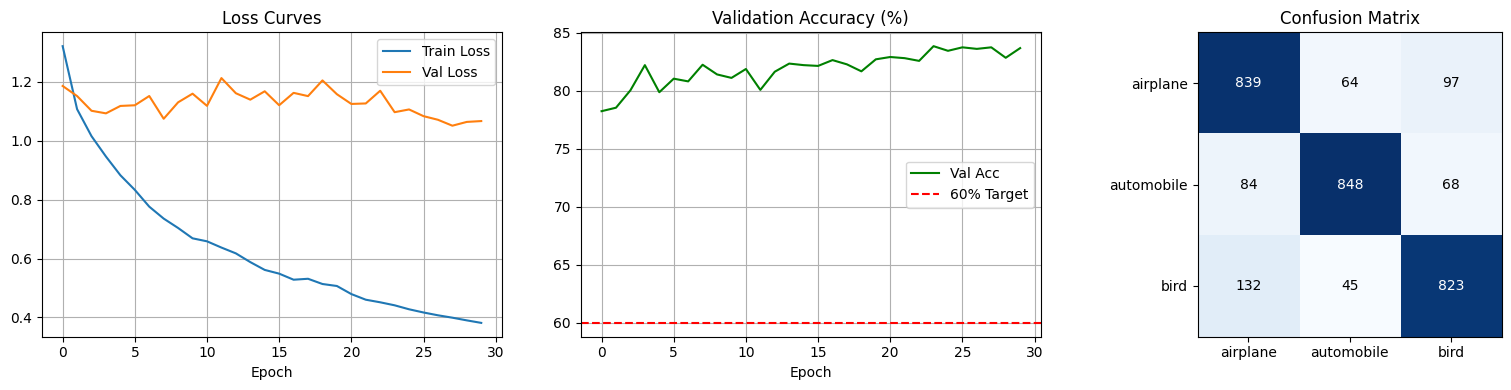

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10

# 1. Dataset dwd and prep

print("Loading CIFAR-10 data...")
train_raw = CIFAR10(root="./data", train=True, download=True)
test_raw = CIFAR10(root="./data", train=False, download=True)

def prepare_subset(dataset, target_classes=[0, 1, 2]):
    images = np.array(dataset.data)
    labels = np.array(dataset.targets)

    mask = np.isin(labels, target_classes)
    images = images[mask]
    labels = labels[mask]

    X = images.reshape(images.shape[0], -1).astype(np.float32)
    class_map = {orig: new for new, orig in enumerate(target_classes)}
    y = np.vectorize(class_map.get)(labels).astype(np.int32)
    return X, y

X_train, y_train = prepare_subset(train_raw, target_classes=[0, 1, 2])
X_test, y_test = prepare_subset(test_raw, target_classes=[0, 1, 2])

# Standardize features to flt 32
mean = np.mean(X_train, axis=0, keepdims=True)
std = np.std(X_train, axis=0, keepdims=True) + 1e-7
X_train = np.ascontiguousarray((X_train - mean) / std, dtype=np.float32)
X_test  = np.ascontiguousarray((X_test - mean) / std, dtype=np.float32)

print(f"Data ready: X_train {X_train.shape}, X_test {X_test.shape}")


# 2. Fast NumPy MLP Architecture

class FastThreeLayerMLP:
    def __init__(self, input_dim=3072, h1=512, h2=128, num_classes=3, reg=1e-3):
        self.reg = np.float32(reg)
        self.params = {
            'W1': (np.random.randn(input_dim, h1) * np.sqrt(2.0 / input_dim)).astype(np.float32),
            'b1': np.zeros((1, h1), dtype=np.float32),
            'W2': (np.random.randn(h1, h2) * np.sqrt(2.0 / h1)).astype(np.float32),
            'b2': np.zeros((1, h2), dtype=np.float32),
            'W3': (np.random.randn(h2, num_classes) * np.sqrt(2.0 / h2)).astype(np.float32),
            'b3': np.zeros((1, num_classes), dtype=np.float32)
        }
        self.velocity = {k: np.zeros_like(v) for k, v in self.params.items()}

    def forward(self, X):
        cache = {}
        cache['Z1'] = np.dot(X, self.params['W1']) + self.params['b1']
        cache['A1'] = np.maximum(0.0, cache['Z1'])

        cache['Z2'] = np.dot(cache['A1'], self.params['W2']) + self.params['b2']
        cache['A2'] = np.maximum(0.0, cache['Z2'])

        cache['Z3'] = np.dot(cache['A2'], self.params['W3']) + self.params['b3']
        shifted = cache['Z3'] - np.max(cache['Z3'], axis=1, keepdims=True)
        exp_z = np.exp(shifted)
        cache['probs'] = exp_z / np.sum(exp_z, axis=1, keepdims=True)
        return cache['probs'], cache

    def compute_loss(self, probs, y):
        m = y.shape[0]
        correct_logprobs = -np.log(probs[np.arange(m), y] + 1e-7)
        data_loss = np.sum(correct_logprobs) / m
        l2_loss = 0.5 * self.reg * (
            np.sum(self.params['W1'] * self.params['W1']) +
            np.sum(self.params['W2'] * self.params['W2']) +
            np.sum(self.params['W3'] * self.params['W3'])
        )
        return data_loss + l2_loss

    def backward(self, X, y, cache):
        m = y.shape[0]
        grads = {}

        dZ3 = cache['probs'].copy()
        dZ3[np.arange(m), y] -= 1.0
        dZ3 *= (1.0 / m)

        grads['W3'] = np.dot(cache['A2'].T, dZ3) + self.reg * self.params['W3']
        grads['b3'] = np.sum(dZ3, axis=0, keepdims=True)

        dA2 = np.dot(dZ3, self.params['W3'].T)
        dZ2 = dA2 * (cache['Z2'] > 0)
        grads['W2'] = np.dot(cache['A1'].T, dZ2) + self.reg * self.params['W2']
        grads['b2'] = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.params['W2'].T)
        dZ1 = dA1 * (cache['Z1'] > 0)
        grads['W1'] = np.dot(X.T, dZ1) + self.reg * self.params['W1']
        grads['b1'] = np.sum(dZ1, axis=0, keepdims=True)
        return grads

    def update_params(self, grads, lr=0.01, momentum=0.9):
        lr = np.float32(lr)
        momentum = np.float32(momentum)
        for k in self.params:
            self.velocity[k] = momentum * self.velocity[k] + lr * grads[k]
            self.params[k] -= self.velocity[k]

    def predict(self, X):
        probs, _ = self.forward(X)
        return np.argmax(probs, axis=1)


# 3. Training Loop

model = FastThreeLayerMLP(input_dim=3072, h1=512, h2=128, num_classes=3, reg=1e-3)
epochs = 30
batch_size = 128
m = X_train.shape[0]
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"Training on {m} samples across {epochs} epochs...")
for epoch in range(1, epochs + 1):
    perm = np.random.permutation(m)
    X_shuf = X_train[perm]
    y_shuf = y_train[perm]

    epoch_loss = 0.0
    num_batches = int(np.ceil(m / batch_size))
    for b in range(num_batches):
        s = b * batch_size
        e = min(s + batch_size, m)
        X_b, y_b = X_shuf[s:e], y_shuf[s:e]

        probs, cache = model.forward(X_b)
        epoch_loss += model.compute_loss(probs, y_b) * (e - s)

        grads = model.backward(X_b, y_b, cache)
        model.update_params(grads, lr=0.01, momentum=0.9)

    train_loss = epoch_loss / m
    val_probs, _ = model.forward(X_test)
    val_loss = model.compute_loss(val_probs, y_test)
    val_acc = np.mean(np.argmax(val_probs, axis=1) == y_test) * 100

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{epochs}] - Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


# 4. Model Evaluation

CLASSES = ["airplane", "automobile", "bird"]
y_pred = model.predict(X_test)
num_classes = len(CLASSES)

cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_test, y_pred):
    cm[t, p] += 1

print("\n" + "=" * 55)
print(f"{'Class':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
for i in range(num_classes):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
    print(f"{CLASSES[i]:<15} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f}")
print("-" * 55)
print(f"Overall Accuracy: {np.trace(cm) / np.sum(cm) * 100:.2f}%\n")

# Display Curves and Matrix
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history['val_acc'], color='green', label='Val Acc')
ax2.axhline(60, color='red', linestyle='--', label='60% Target')
ax2.set_title('Validation Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

im = ax3.imshow(cm, cmap='Blues')
ax3.set_xticks(range(num_classes))
ax3.set_yticks(range(num_classes))
ax3.set_xticklabels(CLASSES)
ax3.set_yticklabels(CLASSES)
ax3.set_title('Confusion Matrix')
for i in range(num_classes):
    for j in range(num_classes):
        ax3.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()